<a href="https://colab.research.google.com/github/aniray2908/ML-foundations-rebuild/blob/main/interpretability/demos/feature_importance_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Importance Demonstration

This notebook demonstrates different methods for measuring feature importance in machine learning models.

We will explore:

- Tree-based feature importance
- Permutation importance
- Correlated feature pitfalls
- Differences between feature usage and model reliance

The goal is to understand how interpretability methods reveal model behavior.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [2]:
X, y = make_regression(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    noise=10,
    random_state=42
)

feature_names = ["feature_1","feature_2","feature_3","feature_4","feature_5"]

X = pd.DataFrame(X, columns=feature_names)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

print("Model R²:", model.score(X_test, y_test))

Model R²: 0.9366291336008968


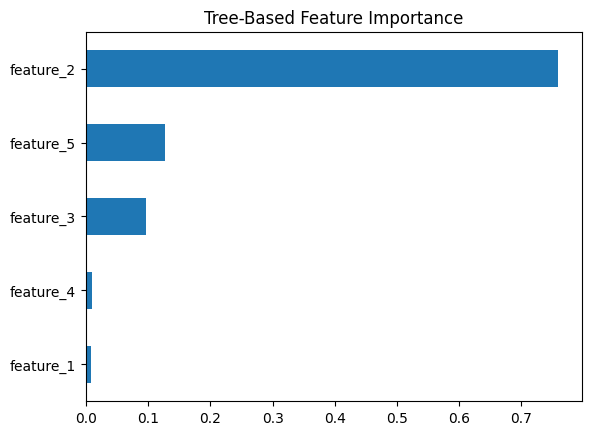

In [4]:
tree_importance = pd.Series(
    model.feature_importances_,
    index=feature_names
)

tree_importance.sort_values().plot(kind="barh")

plt.title("Tree-Based Feature Importance")
plt.show()

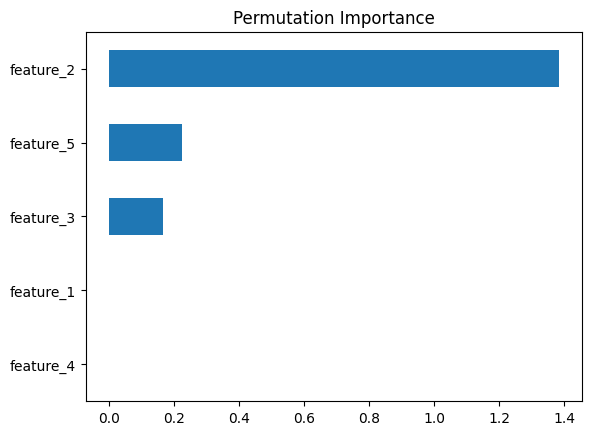

In [5]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=feature_names
)

perm_importance.sort_values().plot(kind="barh")

plt.title("Permutation Importance")
plt.show()

In [6]:
X["feature_1_duplicate"] = X["feature_1"] + np.random.normal(0,0.01,len(X))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

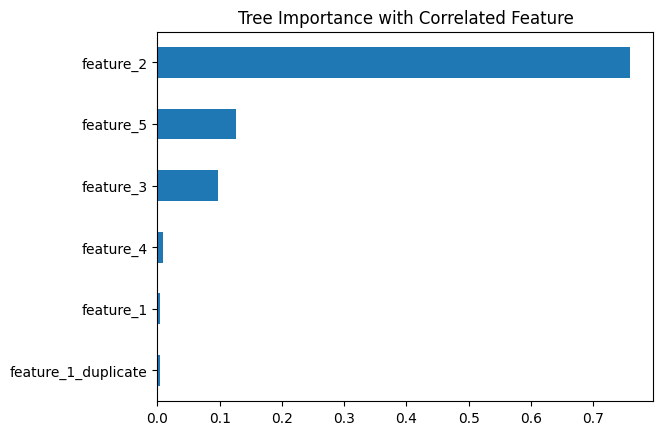

In [8]:
tree_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

tree_importance.sort_values().plot(kind="barh")

plt.title("Tree Importance with Correlated Feature")
plt.show()

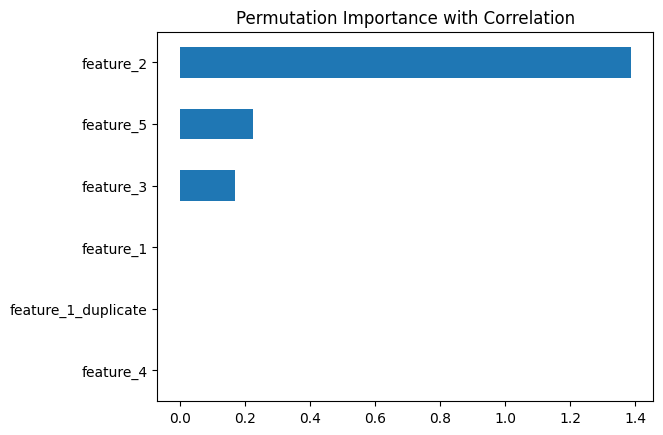

In [9]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
)

perm_importance.sort_values().plot(kind="barh")

plt.title("Permutation Importance with Correlation")
plt.show()

## Key Takeaways

1. Tree-based feature importance measures how often features are used for splits.
2. Continuous and high-cardinality features may receive artificially high importance.
3. Permutation importance measures how much the model relies on a feature.
4. Correlated features can distort both importance measures.
5. Feature importance reflects model behavior, not causal influence.